## Shot Detection Code

In [13]:
from scenedetect import VideoManager, SceneManager
from scenedetect.detectors import ContentDetector

def detect_shots(video_path, threshold=27.0):
    video_manager = VideoManager([video_path])
    scene_manager = SceneManager()
    scene_manager.add_detector(ContentDetector(threshold=threshold))

    video_manager.start()
    scene_manager.detect_scenes(frame_source=video_manager)

    shots = scene_manager.get_scene_list()
    video_manager.release()
    return shots

Testing on One Video

In [14]:
video_path = "../data/raw_videos/_Floral_ by ADIDAS - AI Spec AD.mp4"
shots = detect_shots(video_path)

for i, (start, end) in enumerate(shots):
    print(f"Shot {i+1}: {start.get_seconds():.2f} - {end.get_seconds():.2f}")


VideoManager is deprecated and will be removed.


Shot 1: 0.00 - 1.50
Shot 2: 1.50 - 2.34
Shot 3: 2.34 - 3.17
Shot 4: 3.17 - 4.17
Shot 5: 4.17 - 5.30
Shot 6: 5.30 - 6.09
Shot 7: 6.09 - 6.80
Shot 8: 6.80 - 8.22
Shot 9: 8.22 - 9.13
Shot 10: 9.13 - 10.51
Shot 11: 10.51 - 12.18
Shot 12: 12.18 - 13.97
Shot 13: 13.97 - 14.76
Shot 14: 14.76 - 16.73
Shot 15: 16.73 - 17.77
Shot 16: 17.77 - 19.10
Shot 17: 19.10 - 20.23
Shot 18: 20.23 - 21.02
Shot 19: 21.02 - 21.69
Shot 20: 21.69 - 22.98
Shot 21: 22.98 - 23.73
Shot 22: 23.73 - 25.15
Shot 23: 25.15 - 27.90
Shot 24: 27.90 - 28.40


## Running Shots_Detection on all the data sample

In [15]:
import os

video_dir = "../data/raw_videos"
all_shots = {}

for video in os.listdir(video_dir):
    if video.endswith(".mp4"):
        path = os.path.join(video_dir, video)
        all_shots[video] = detect_shots(path)


VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be r

In [16]:
all_shots

{'16 0613 PROJ COLOR CHEF.mp4': [(00:00:00.000 [frame=0, fps=23.976],
   00:00:02.002 [frame=48, fps=23.976]),
  (00:00:02.002 [frame=48, fps=23.976], 00:00:03.128 [frame=75, fps=23.976]),
  (00:00:03.128 [frame=75, fps=23.976], 00:00:04.463 [frame=107, fps=23.976]),
  (00:00:04.463 [frame=107, fps=23.976], 00:00:05.297 [frame=127, fps=23.976]),
  (00:00:05.297 [frame=127, fps=23.976], 00:00:06.006 [frame=144, fps=23.976]),
  (00:00:06.006 [frame=144, fps=23.976], 00:00:07.174 [frame=172, fps=23.976]),
  (00:00:07.174 [frame=172, fps=23.976], 00:00:08.634 [frame=207, fps=23.976]),
  (00:00:08.634 [frame=207, fps=23.976], 00:00:10.177 [frame=244, fps=23.976]),
  (00:00:10.177 [frame=244, fps=23.976], 00:00:11.053 [frame=265, fps=23.976]),
  (00:00:11.053 [frame=265, fps=23.976], 00:00:12.512 [frame=300, fps=23.976]),
  (00:00:12.512 [frame=300, fps=23.976], 00:00:13.430 [frame=322, fps=23.976]),
  (00:00:13.430 [frame=322, fps=23.976], 00:00:14.306 [frame=343, fps=23.976]),
  (00:00:14.

## Extract ONE Keyframe per Shot

In [17]:
from scenedetect.scene_manager import save_images

import os

def extract_keyframes(video_path, shots, output_dir):
    os.makedirs(output_dir, exist_ok=True)  # Create output folder if it doesn't exist
    video_manager = VideoManager([video_path])
    video_manager.start()

    save_images(
        shots,
        video_manager,
        num_images=1,
        output_dir=output_dir,
        image_name_template='shot_$SCENE_NUMBER'
    )

    video_manager.release()


Running for One Video

In [18]:
# extract_keyframes(
#     "../data/raw_videos/_Floral_ by ADIDAS - AI Spec AD.mp4",
#     shots,
#     "../data/segmentation/ad_01/keyframes"
# )


## Extract Visual Embeddings (CLIP)

In [19]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def get_embedding(image_path):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(image)
    emb /= emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy()

def extract_embeddings_for_all_shots(keyframes_dir):
    embeddings = []
    for keyframe in os.listdir(keyframes_dir):
        if keyframe.endswith(".jpg"):  # Only process image files
            keyframe_path = os.path.join(keyframes_dir, keyframe)
            embedding = get_embedding(keyframe_path)
            embeddings.append(embedding)
    return embeddings

# Example usage
keyframes_dir = "../data/segmentation/ad_01/keyframes"
embeddings = extract_embeddings_for_all_shots(keyframes_dir)


## Group Shots into Scenes

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

def group_shots_into_scenes(shots, embeddings, threshold=0.85):
    scenes = []
    current_scene = {"shots": [0]}

    for i in range(len(embeddings) - 1):
        sim = cosine_similarity(embeddings[i], embeddings[i+1])[0][0]
        if sim >= threshold:
            current_scene["shots"].append(i+1)
        else:
            scenes.append(current_scene)
            current_scene = {"shots": [i+1]}

    scenes.append(current_scene)
    return scenes


## Build Final Scene → Shot Structure

In [24]:
def build_scene_hierarchy(video_name, shots, scenes):
    hierarchy = {
        "video": video_name,
        "scenes": []
    }

    for i, scene in enumerate(scenes):
        scene_shots = []
        for shot_idx in scene["shots"]:
            # Ensure shot_idx is within bounds
            if shot_idx < len(shots):
                start, end = shots[shot_idx]
                scene_shots.append({
                    "shot_id": shot_idx + 1,
                    "start": start.get_seconds(),
                    "end": end.get_seconds()
                })
            else:
                print(f"Warning: Shot index {shot_idx} out of range for {video_name}. Skipping.")

        hierarchy["scenes"].append({
            "scene_id": i + 1,
            "shots": scene_shots
        })

    return hierarchy


## Saving Results

In [25]:
import json
video_dir = "../data/raw_videos"
output_dir = "../data/segmentation"
all_shots = {}

# Loop through videos
for video in os.listdir(video_dir):
    if video.endswith(".mp4"):
        video_path = os.path.join(video_dir, video)
        
        # Step 1: Detect shots
        shots = detect_shots(video_path)
        
        # Step 2: Extract keyframes
        keyframes_dir = os.path.join(output_dir, video.replace(".mp4", "/keyframes"))
        extract_keyframes(video_path, shots, keyframes_dir)

        # Step 3: Generate embeddings
        embeddings = []
        for keyframe in os.listdir(keyframes_dir):
            keyframe_path = os.path.join(keyframes_dir, keyframe)
            embedding = get_embedding(keyframe_path)
            embeddings.append(embedding)
        
        # Step 4: Group shots into scenes
        scenes = group_shots_into_scenes(shots, embeddings)

        # Step 5: Build hierarchy
        hierarchy = build_scene_hierarchy(video, shots, scenes)

        # Step 6: Save results
        output_file = os.path.join(output_dir, video.replace(".mp4", "_scenes.json"))
        with open(output_file, "w") as f:
            json.dump(hierarchy, f, indent=2)

        print(f"Processed and saved hierarchy for {video} to {output_file}")

VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.


Processed and saved hierarchy for 16 0613 PROJ COLOR CHEF.mp4 to ../data/segmentation\16 0613 PROJ COLOR CHEF_scenes.json


VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.


Processed and saved hierarchy for 6607010_2158732_DE_de_9000D_Winter Sale_Feed&Masthead_YT_Women_Step2_16x9_20s_D.mp4 - H&M (720p, h264, youtube).mp4 to ../data/segmentation\6607010_2158732_DE_de_9000D_Winter Sale_Feed&Masthead_YT_Women_Step2_16x9_20s_D_scenes.json - H&M (720p, h264, youtube)_scenes.json


VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.


...

Processed and saved hierarchy for W16 TV Ad.mp4 to ../data/segmentation\W16 TV Ad_scenes.json


VideoManager is deprecated and will be removed.
VideoManager is deprecated and will be removed.


Processed and saved hierarchy for Who will you Share A Coke with_.mp4 to ../data/segmentation\Who will you Share A Coke with__scenes.json


VideoManager is deprecated and will be removed.


Processed and saved hierarchy for _Floral_ by ADIDAS - AI Spec AD.mp4 to ../data/segmentation\_Floral_ by ADIDAS - AI Spec AD_scenes.json


## Visualizing Shot Boundaries

VideoManager is deprecated and will be removed.


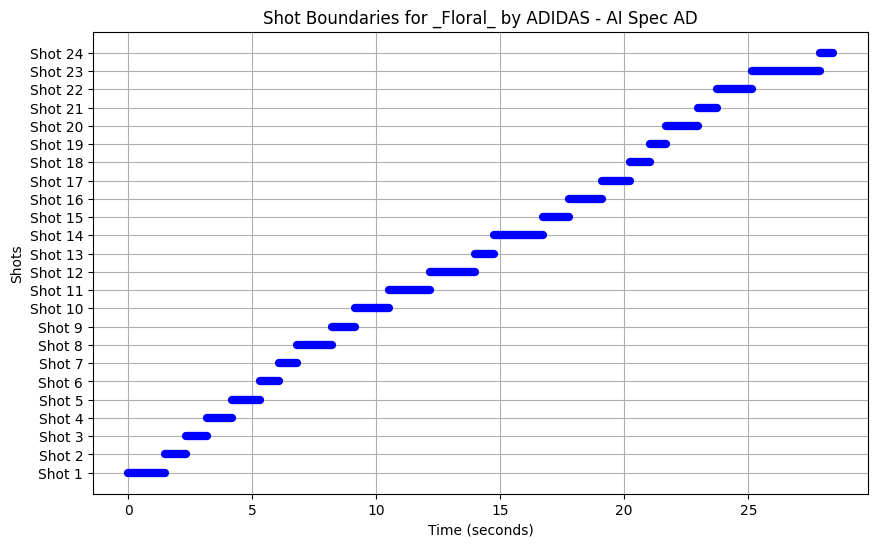

In [ ]:
import matplotlib.pyplot as plt


def plot_shot_boundaries(video_name, shots):
   
    shot_times = [(start.get_seconds(), end.get_seconds()) for start, end in shots]
    
 
    plt.figure(figsize=(10, 6))
    plt.title(f"Shot Boundaries for {video_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Shots")
    
    for i, (start_time, end_time) in enumerate(shot_times):
        plt.plot([start_time, end_time], [i, i], lw=6, color='blue', solid_capstyle="round")  # Horizontal line for each shot
        
    plt.yticks(range(len(shot_times)), [f"Shot {i+1}" for i in range(len(shot_times))])
    plt.grid(True)
    plt.show()


video_path = "../data/raw_videos/_Floral_ by ADIDAS - AI Spec AD.mp4"
shots = detect_shots(video_path)
plot_shot_boundaries("_Floral_ by ADIDAS - AI Spec AD", shots)
